In [21]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Load audio
audio, sr = librosa.load("my_audio.wav", sr=None)

In [23]:
audio.shape

(144000,)

In [24]:
print("Sample Rate:", sr)
print("Number of Samples:", len(audio))

Sample Rate: 48000
Number of Samples: 144000


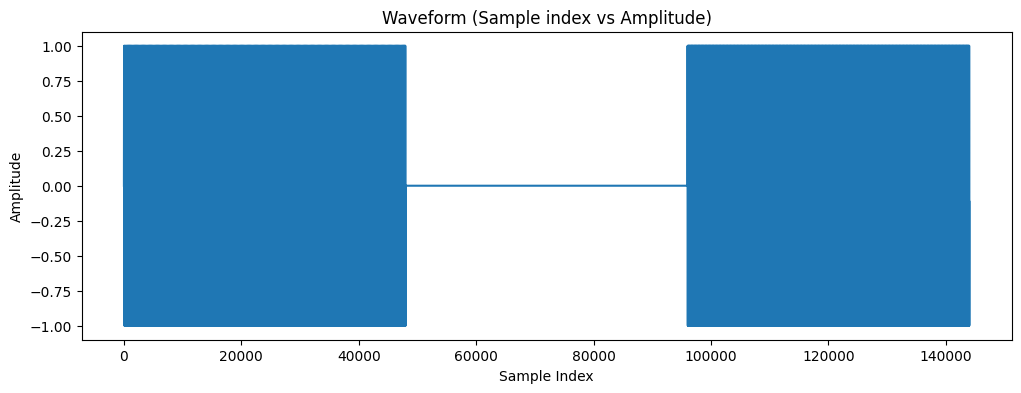

In [25]:
# Plot waveform
plt.figure(figsize=(12, 4))
plt.plot(audio)

plt.title("Waveform (Sample index vs Amplitude)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")

plt.show()

Time is derived from the sample index and sample rate using the formula:

t=n/fs

Where:
- t  = time (seconds)
- n  = sample index
- fs = sample rate (samples per second)

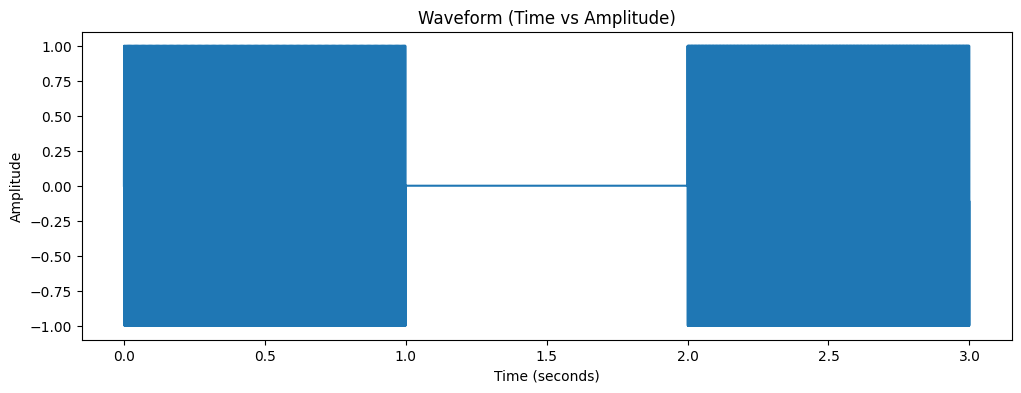

In [26]:
# Create time axis
time = np.arange(len(audio)) / sr

# Plot waveform
plt.figure(figsize=(12, 4))
plt.plot(time, audio)

plt.title("Waveform (Time vs Amplitude)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [27]:
# Each number represents the air pressure at one instant.
audio[:10]

array([0.        , 0.05755615, 0.1149292 , 0.17190552, 0.22833252,
       0.28399658, 0.3387146 , 0.39230347, 0.4446106 , 0.49542236],
      dtype=float32)

The above waveform is hard to interpret right ? 

So the question is Can we break a complex waveform into simpler sine waves?

Answer is yes. Any sound signal can be thought of as: Sum of many sine waves with different frequencies

This is the basis of Fourier analysis, which allows us to analyze the frequency content of a signal.

It converts:

x(t)→X(f)

Where:
- x(t) is the time-domain signal (waveform)
- X(f) is the frequency-domain representation (spectrum)

In [28]:
# FFT
fft = np.fft.rfft(audio)
freqs = np.fft.rfftfreq(len(audio), d=1/sr)

# Magnitude spectrum
magnitude = np.abs(fft)

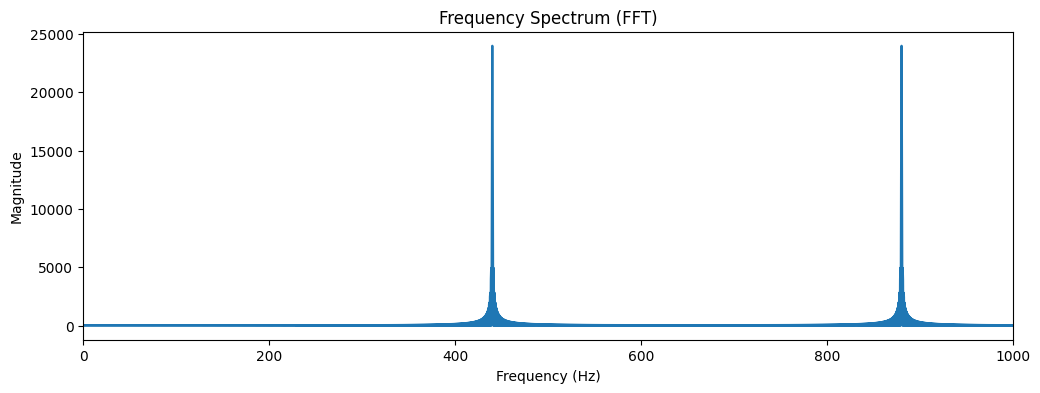

In [29]:
plt.figure(figsize=(12,4))
plt.plot(freqs, magnitude)
plt.title("Frequency Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 1000)
plt.show()

### So fft gave us the overall frequency content of the signal. But, does it tell us when those frequencies occur?

##### No, right ? That leads us to Short Time Fourier Transform (STFT) which gives us the frequency content at each moment in time.

## STFT => STFT = sliding FFT

Instead of analyzing the whole signal at once:
- Take a short window (e.g., 20–40 ms)
- Apply FFT → frequency content of that slice
- Move window forward
- Repeat

This gives us a time-frequency representation:
x(t)→X(t,f)

Where:
- x(t) is the time-domain signal (waveform)
- X(t,f) is the time-frequency representation (spectrogram)

In [30]:
# STFT computation
# Window size = 1024 samples
# move window by 512 samples, overlap exists (important for smoothness)

stft = librosa.stft(audio, n_fft=1024, hop_length=512)

# Convert to magnitude
magnitude = np.abs(stft)

db = librosa.amplitude_to_db(magnitude)

db.shape

(513, 282)

In [31]:
time_frame_ms = (1024/sr)  * 1000 
print(f"Time frame = {time_frame_ms:.4} ms") 

no_of_frames = db.shape[1]
print(f"No. of frames = {no_of_frames}")

frequency_bins = db.shape[0]
print(f"No. of frequency bins = {frequency_bins}")

Time frame = 21.33 ms
No. of frames = 282
No. of frequency bins = 513


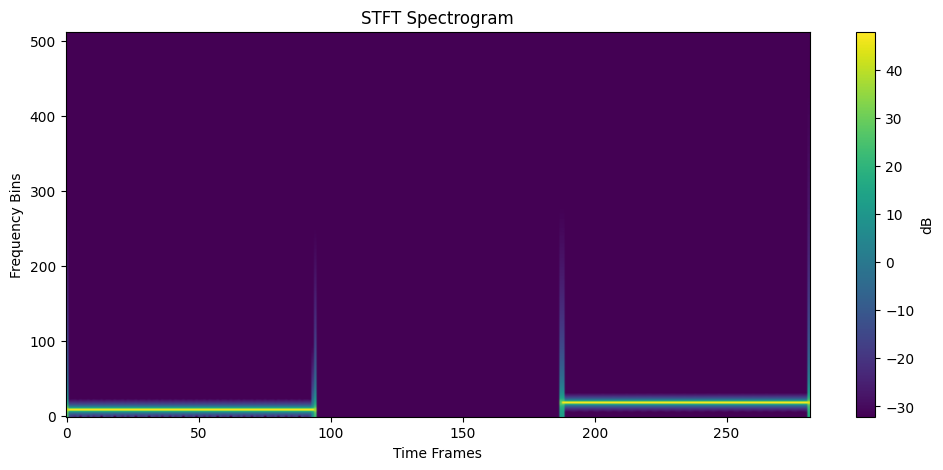

In [32]:
plt.figure(figsize=(12, 5))
plt.imshow(db, aspect='auto', origin='lower')
plt.title("STFT Spectrogram")
plt.xlabel("Time Frames")
plt.ylabel("Frequency Bins")
plt.colorbar(label="dB")
plt.show()

- bright horizontal band → stable frequency structure (vowel sound)
- vertical spike → sudden energy (consonant sound)
- dark region → silence

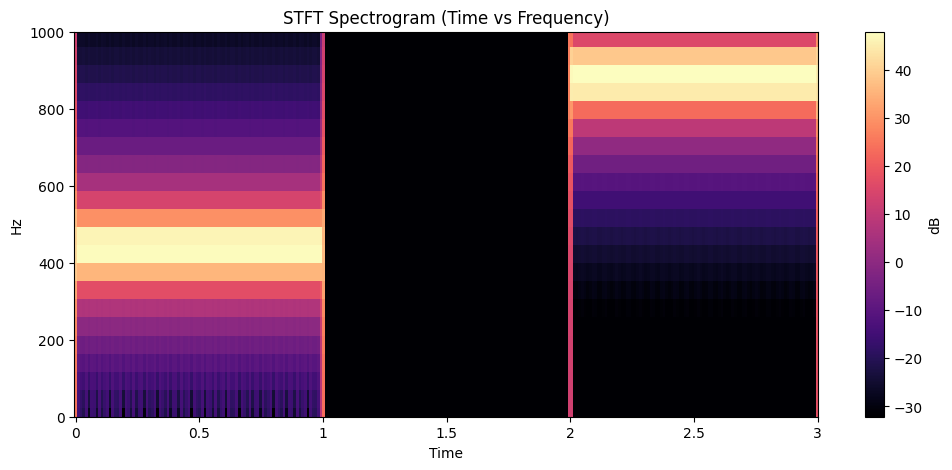

In [42]:
plt.figure(figsize=(12,5))
librosa.display.specshow(db, sr=sr, hop_length=512, x_axis='time', y_axis='hz')
plt.ylim(0, 1000)
plt.colorbar(label="dB")
plt.title("STFT Spectrogram (Time vs Frequency)")
plt.show()

In STFT, It gave us linear frequency scale (Hz), the resolution is the same across all frequencies

Resolution means how well we can distinguish between two frequencies.

But do you know human hearing is NOT linear.

We can distinguish between 100 Hz and 200 Hz but not between 10,100 Hz and 10,200 Hz.
i.e We have `better resolution at lower frequencies` than higher frequencies.

So STFT is mathematically correct but not perceptually optimal.

That leads us to `Mel Spectrogram` which gives us better resolution at lower frequencies and less resolution at higher frequencies, matching human hearing.

Mel scale is a transformation:

fmel = 2595 log(1+f/700)

Meaning:
- low frequencies → expanded
- high frequencies → compressed

In [34]:
# Mel spectrogram
# Divide frequency range (0–8kHz if 16kHz audio) into 128 Mel bands
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel.shape

(128, 282)

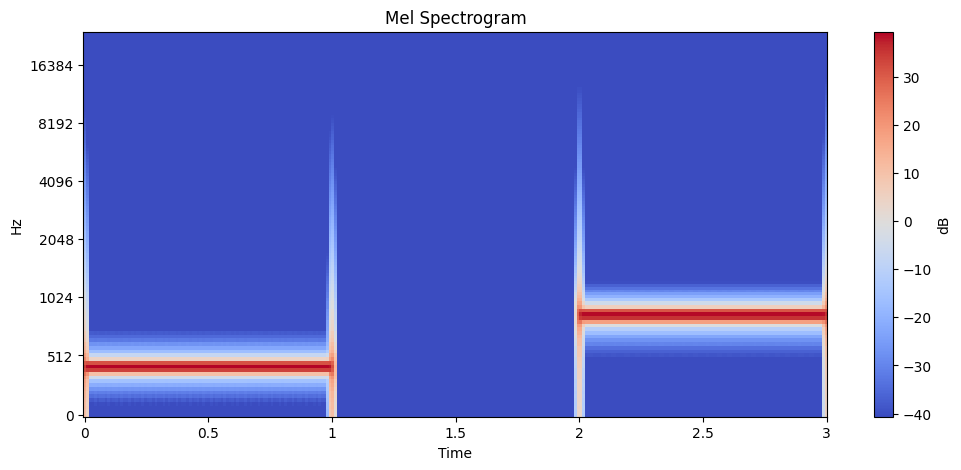

In [35]:
# Convert to log scale
mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(12,5))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(label="dB")
plt.title("Mel Spectrogram")
plt.show()

Mel spectrogram is still:

- high-dimensional
- correlated across frequency bands because of the overlappings

That leads to MFCC (Mel Frequency Cepstral Coefficients) which gives us a compact representation of the sepctrum.

MFCC solves this by:

compressing spectral information into a small feature vector

which: 
- compresses Mel features
- removes correlation between frequency bands

In [41]:
# MFCC = compressed version of Mel spectrogram
# So instead of 128 Mel bands we compress to 13 numbers

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13 # Keep only 13 coefficients per frame
)

mfcc.shape

(13, 282)

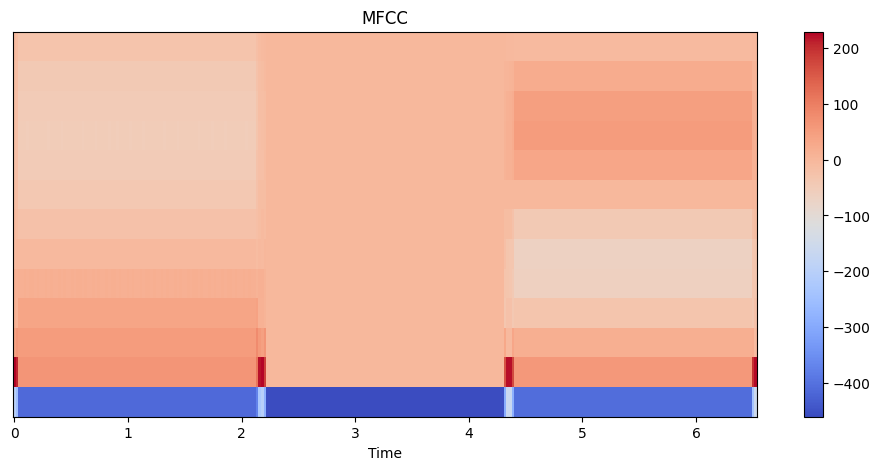

In [37]:
plt.figure(figsize=(12,5))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC")
plt.show()

Earlier systems used MFCC because:

- compact
- stable
- speaker-dependent

But problem:

MFCC removes fine spectral detail

So modern artifacts disappear.

That is why:

- ASVspoof moved to log-Mel
- AASIST uses spectro-temporal graphs
- SSL models (wav2vec) are now dominant